# D-RF2-D — Hierarchical interaction architecture vs flat 7-way mapping

**research_question**: SSOT 01 §5 의 flat 7-way branch tree 대신, 각 branch 의 Endpoint 절에서
유도한 **interaction primitive 를 먼저 구분하는 계층 구조**가 관측 가능한 evidence 와 더 잘 맞는가?

- `child_id` = `D-RF2-D` · parent RQ `RQ-D-RF-002`
- `hypothesis_id` = `H-RF2-D-HIERARCHY`
- MLflow run_id = `889eccf791a94f08938efcbc7df0dfc4` (experiment `LA_03_RF_MAPPING`, parent `ae754858ba3a4be391e5f811640d3fd8`)

**최종 output 공간은 frozen 7 archetype 그대로다.** Level 1 primitive 는 중간 단계이며 leaf 가 아니다.
`prior_archetype` 은 gold label 이 아니라 prior 이므로 accuracy 가 아니라 `prior_agreement` 로만 부른다.


In [1]:
import hashlib, json
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown

RD  = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/research/landing_accessibility/research_d")
RES = RD / "results" / "RF2_D_hierarchical.json"
doc = json.loads(RES.read_text(encoding="utf-8"))
sha = lambda p: hashlib.sha256(Path(p).read_bytes()).hexdigest()

header = {
    "research_question": "interaction primitive 를 먼저 구분하는 계층이 관측 evidence 와 더 잘 맞는가",
    "child_id":        doc["child_id"],
    "rq_id":           doc["rq_id"],
    "hypothesis_id":   doc["hypothesis_id"],
    "mlflow_run_id":   "889eccf791a94f08938efcbc7df0dfc4",
    "parent_run_id":   doc["parent_run_id"],
    "analysis_unit":   doc["analysis_unit"],
    "grain":           "target (wtg), in_mart==1",
    "n_expected":      doc["n_expected"],
    "n_observed":      doc["n_observed"],
    "missing_n":       doc["missing_n"],
    "seed":            doc["seed"],
    "rule_version":    doc["rule_version"],
    "verdict":         doc["verdict"],
    "code_sha":        sha(RD / "tools" / "rf2_d_hierarchical.py"),
    "result_sha":      sha(RES),
}
for i in doc["inputs"]:
    header["input_sha :: " + Path(i["path"]).name] = i["sha256"]
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 90)
display(pd.Series(header, name="value").to_frame())

,value
research_question,interaction primitive 를 먼저 구분하는 계층이 관측 evidence 와 더 잘 맞는가
child_id,D-RF2-D
rq_id,RQ-D-RF-002
hypothesis_id,H-RF2-D-HIERARCHY
mlflow_run_id,889eccf791a94f08938efcbc7df0dfc4
parent_run_id,ae754858ba3a4be391e5f811640d3fd8
analysis_unit,"web target (wtg), in_mart==1"
grain,"target (wtg), in_mart==1"
n_expected,59
n_observed,56


## 1. Level 1 정의와 SSOT §5 근거 (데이터를 보기 전에 고정)

In [2]:
L1 = doc["level1"]
print("정의 출처:", L1["definition_source"])
for p, ms in L1["primitives"].items():
    print(f"  {p:24s} -> {', '.join(ms)}")
print()
print("SSOT §5 branch tree 는 primitive 위의 분할인가? ->", L1["is_partition_of_7"])
print("primitive 2개에 걸친 archetype:", L1["multi_primitive_archetypes"])
print()
print("최종 output 공간:", doc["final_output_space"])
print(doc["construct_note"])

정의 출처: SSOT 01 §5 각 branch 의 Endpoint 절
  L1_QUERY_SUBMISSION      -> QUERY, PLACE_LOOKUP
  L1_OBJECT_OPENING        -> CONTENT_OPEN, ITEM_DETAIL, PLACE_LOOKUP, COMMUNICATION_ENTRY
  L1_AUTH_ACTION_ENTRY     -> FINANCIAL_ACTION_ENTRY, COMMUNICATION_ENTRY
  L1_UTILITY_TOOL_ENTRY    -> UTILITY_ENTRY

SSOT §5 branch tree 는 primitive 위의 분할인가? -> False
primitive 2개에 걸친 archetype: ['PLACE_LOOKUP', 'COMMUNICATION_ENTRY']

최종 output 공간: ['QUERY', 'CONTENT_OPEN', 'ITEM_DETAIL', 'PLACE_LOOKUP', 'COMMUNICATION_ENTRY', 'FINANCIAL_ACTION_ENTRY', 'UTILITY_ENTRY', 'ABSTAIN']
최종 leaf 는 frozen 7 archetype 그대로다. Level 1 primitive 는 중간 단계이며 leaf 가 아니다. 새 class 를 만들지 않았다.


## 2. 세 구조 비교 — 동일 최종 7-way output 기준 (n=56)

In [3]:
lab = {"flat": "S1 flat rule", "hier_rule": "S2 hier rule", "hier_strict": "S2s hier strict",
       "hier_sem": "S3 hier+semantic", "hier_sem_m02": "S3m hier+sem margin.02"}
rows = []
for k in ["flat", "hier_rule", "hier_strict", "hier_sem", "hier_sem_m02"]:
    s = doc["structures"][k]
    ci  = s["coverage_ci"]; ca = s["prior_agreement_within_coverage_ci"]
    rows.append({
        "structure": lab[k], "mapped": s["n_mapped"], "n": s["n"],
        "coverage": round(s["coverage"], 3),
        "coverage 95% CI": f"[{ci[0]:.3f}, {ci[1]:.3f}]",
        "abstention": round(s["abstention_rate"], 3),
        "prior_agree | coverage": s["prior_agreement_within_coverage_fraction"],
        "  rate": round(s["prior_agreement_within_coverage"], 3),
        "  95% CI": f"[{ca[0]:.3f}, {ca[1]:.3f}]",
        "prior_agree overall": s["prior_agreement_overall_fraction"],
    })
display(pd.DataFrame(rows).set_index("structure"))
display(Markdown("**모든 CI 가 서로 겹친다 — 어떤 구조도 다른 구조와 구별되지 않는다.**"))

,mapped,n,coverage,coverage 95% CI,abstention,prior_agree | coverage,rate,95% CI,prior_agree overall
structure,,,,,,,,,
S1 flat rule,14,56,0.250,"[0.155, 0.377]",0.750,5/14,0.357,"[0.163, 0.612]",5/56
S2 hier rule,16,56,0.286,"[0.184, 0.415]",0.714,5/16,0.312,"[0.142, 0.556]",5/56
S2s hier strict,11,56,0.196,"[0.113, 0.318]",0.804,4/11,0.364,"[0.152, 0.646]",4/56
S3 hier+semantic,16,56,0.286,"[0.184, 0.415]",0.714,6/16,0.375,"[0.185, 0.614]",6/56
S3m hier+sem margin.02,9,56,0.161,"[0.087, 0.278]",0.839,5/9,0.556,"[0.267, 0.811]",5/56


**모든 CI 가 서로 겹친다 — 어떤 구조도 다른 구조와 구별되지 않는다.**

## 3. Level 별 분해 — 조건부 분모를 명시한다

In [4]:
n = doc["n_observed"]
L2 = doc["level2_conditional"]
r = [
 ["Level 1 coverage",              "56 (전체 target)", f'{L1["n_l1_resolved"]}/{n}', round(L1["l1_coverage"], 3),
  f'[{L1["l1_coverage_ci"][0]:.3f}, {L1["l1_coverage_ci"][1]:.3f}]'],
 ["Level 1 abstention",            "56", f'{n - L1["n_l1_resolved"]}/{n}', round(L1["l1_abstention"], 3), ""],
]
for name in ["hier_rule", "hier_sem", "hier_sem_m02"]:
    b = L2[name]
    r.append([f"Level 2 coverage ({name})", "16 (Level 1 이 유일 primitive 를 확정한 건)",
              f'{b["n_level2_mapped"]}/{b["n_level1_passed"]}',
              round(b["level2_coverage_conditional"], 3),
              f'[{b["level2_coverage_conditional_ci"][0]:.3f}, {b["level2_coverage_conditional_ci"][1]:.3f}]'])
    ci = b["prior_agreement_within_level2_coverage_ci"]
    r.append([f"Level 2 prior_agreement ({name})", "Level 2 가 매핑한 건", b["fraction"],
              round(b["prior_agreement_within_level2_coverage"], 3), f"[{ci[0]:.3f}, {ci[1]:.3f}]"])
display(pd.DataFrame(r, columns=["지표", "분모", "fraction", "값", "Wilson 95%"]).set_index("지표"))
display(Markdown("> Level 2 조건부 coverage 1.000 은 **정의상 산물**이다:\n> "
                 + doc["hierarchy_easiness_check"]["l2_conditional_coverage_is_an_artifact"]))

,분모,fraction,값,Wilson 95%
지표,,,,
Level 1 coverage,56 (전체 target),16/56,0.286,"[0.184, 0.415]"
Level 1 abstention,56,40/56,0.714,
Level 2 coverage (hier_rule),16 (Level 1 이 유일 primitive 를 확정한 건),16/16,1.000,"[0.806, 1.000]"
Level 2 prior_agreement (hier_rule),Level 2 가 매핑한 건,5/16,0.312,"[0.142, 0.556]"
Level 2 coverage (hier_sem),16 (Level 1 이 유일 primitive 를 확정한 건),16/16,1.000,"[0.806, 1.000]"
Level 2 prior_agreement (hier_sem),Level 2 가 매핑한 건,6/16,0.375,"[0.185, 0.614]"
Level 2 coverage (hier_sem_m02),16 (Level 1 이 유일 primitive 를 확정한 건),9/16,0.562,"[0.332, 0.769]"
Level 2 prior_agreement (hier_sem_m02),Level 2 가 매핑한 건,5/9,0.556,"[0.267, 0.811]"


> Level 2 조건부 coverage 1.000 은 **정의상 산물**이다:
> hier_rule 의 Level 2 조건부 coverage 가 1.0 인 것은 L2 가 쉬워서가 아니다. L1_QUERY_SUBMISSION 의 L2 판별식(QUERY = 검색표면 ∧ ¬장소, PLACE = 장소)은 상호배타적으로 선언되어 있어 L1 이 통과하면 반드시 정확히 하나가 발화한다. L1_UTILITY_TOOL_ENTRY 는 member 가 1 개라 L2 가 항상 참이다. 즉 L2 는 abstain 하지 않도록 정의된 구간을 포함하며, 그 대가가 L2 prior_agreement 저하로 나타난다.

## 4. 어디서 정보를 잃는가 — Level 1 이 병목이다

In [5]:
flat_o = doc["structures"]["flat"]["outcome_counts"]
hier_o = doc["structures"]["hier_rule"]["outcome_counts"]
loss = pd.DataFrame({
    "S1 flat": [flat_o.get("S0_UNDETERMINED", 0), flat_o.get("ABSTAIN_NO_BRANCH", 0),
                flat_o.get("ABSTAIN_MULTI_BRANCH", 0), 0, 0, flat_o.get("MAPPED", 0)],
    "S2 hier": [hier_o.get("S0_UNDETERMINED", 0), hier_o.get("ABSTAIN_L1_NONE", 0),
                hier_o.get("ABSTAIN_L1_MULTI", 0), hier_o.get("ABSTAIN_L2_MULTI", 0),
                hier_o.get("ABSTAIN_L2_NONE", 0), hier_o.get("MAPPED", 0)]},
    index=["Stage 0 undetermined", "강후보 0개 (L1 none)", "강후보 2개+ (L1 multi)",
           "Level 2 다중 tie", "Level 2 없음", "MAPPED"])
display(loss)

from collections import Counter
c = Counter(tuple(x["l1_strong"]) for x in doc["rows"] if x["l1_outcome"] == "ABSTAIN_L1_MULTI")
display(pd.Series({" + ".join(p.replace("L1_", "") for p in k): v for k, v in c.most_common()},
                  name="targets").to_frame().rename_axis("Level 1 에서 충돌한 primitive 조합"))

,S1 flat,S2 hier
Stage 0 undetermined,6,6
강후보 0개 (L1 none),21,19
강후보 2개+ (L1 multi),15,15
Level 2 다중 tie,0,0
Level 2 없음,0,0
MAPPED,14,16


,targets
Level 1 에서 충돌한 primitive 조합,
OBJECT_OPENING + QUERY_SUBMISSION,7
QUERY_SUBMISSION + UTILITY_TOOL_ENTRY,2
OBJECT_OPENING + QUERY_SUBMISSION + UTILITY_TOOL_ENTRY,2
AUTH_ACTION_ENTRY + QUERY_SUBMISSION,1
OBJECT_OPENING + UTILITY_TOOL_ENTRY,1
AUTH_ACTION_ENTRY + UTILITY_TOOL_ENTRY,1
AUTH_ACTION_ENTRY + QUERY_SUBMISSION + UTILITY_TOOL_ENTRY,1


## 5. 계층이 좋아 보이는 것이 문제를 쉽게 만든 것 아닌가

In [6]:
E = doc["hierarchy_easiness_check"]
print(E["question"], "\n")
print("(a)", E["rule_1_never_compare_l1_to_7way"], "\n")
mb = E["l1_majority_baseline_on_l1_resolved"]; ob = E["l1_observed_agreement_on_l1_resolved"]
display(pd.DataFrame([
  ["L1 확정 16건에서의 prior primitive 일치", f'{ob["k"]}/{ob["n"]}', round(ob["rate"], 4),
   f'[{ob["ci"][0]:.3f}, {ob["ci"][1]:.3f}]'],
  ["같은 16건, '항상 OBJECT_OPENING' 다수결 기준선", f'{mb["k"]}/{mb["n"]}', round(mb["rate"], 4),
   f'[{mb["ci"][0]:.3f}, {mb["ci"][1]:.3f}]'],
  ["전체 56건 다수결 기준선", f'{E["l1_majority_baseline_all56"]["k"]}/56',
   round(E["l1_majority_baseline_all56"]["rate"], 4),
   f'[{E["l1_majority_baseline_all56"]["ci"][0]:.3f}, {E["l1_majority_baseline_all56"]["ci"][1]:.3f}]'],
], columns=["(b) 지표", "fraction", "rate", "Wilson 95%"]).set_index("(b) 지표"))

crt = E["candidate_restriction_test"]
display(pd.Series({
  "동일 Level-1 통과 건수": crt["n"],
  "계층 없이 7-way semantic argmax 일치": crt["unrestricted_7way_agree"],
  "Level 1 제약 후 argmax 일치": crt["l1_restricted_agree"],
  "불일치: 제약 없을 때만 맞음": crt["discordant_unrestricted_only"],
  "불일치: 제약했을 때만 맞음": crt["discordant_restricted_only"],
  "McNemar exact p": crt["mcnemar_exact_p"],
}, name="(c) 후보 제약이 정보를 더하는가").to_frame())

print()
print("(d) 참고 대조 —", doc["flat_semantic_reference"]["note"])
print("    prior 일치:", doc["flat_semantic_reference"]["fraction"],
      f'= {doc["flat_semantic_reference"]["prior_agreement_overall"]:.3f}',
      "(abstention 0 — 정책이 달라 위 표와 같은 줄에 놓을 수 없다)")

계층이 좋아 보이는 것이 단지 Level 1 이 class 를 뭉쳐 문제를 쉽게 만든 것 아닌가 

(a) L1 은 4-way(그나마 2 개 archetype 은 primitive 2 개에 중복 소속)이고 최종은 7-way 다. 분모와 class 수가 달라 직접 비교하지 않았다. 



,fraction,rate,Wilson 95%
(b) 지표,,,
L1 확정 16건에서의 prior primitive 일치,9/16,0.5625,"[0.332, 0.769]"
"같은 16건, '항상 OBJECT_OPENING' 다수결 기준선",13/16,0.8125,"[0.570, 0.934]"
전체 56건 다수결 기준선,37/56,0.6607,"[0.530, 0.771]"


,(c) 후보 제약이 정보를 더하는가
동일 Level-1 통과 건수,16.000
계층 없이 7-way semantic argmax 일치,9.000
Level 1 제약 후 argmax 일치,6.000
불일치: 제약 없을 때만 맞음,4.000
불일치: 제약했을 때만 맞음,1.000
McNemar exact p,0.375



(d) 참고 대조 — Level 1 이 실제로 후보를 제약하는지 확인하기 위한 참고 대조. 계층 없이 7-way semantic argmax 를 전부 강제 매핑한 경우.
    prior 일치: 29/56 = 0.518 (abstention 0 — 정책이 달라 위 표와 같은 줄에 놓을 수 없다)


## 6. flat vs hier 짝지은 차이 (동일 최종 7-way output)

In [7]:
D = doc["structure_delta_flat_vs_hier"]
display(pd.Series({
  "같이 매핑 · 예측 동일":   len(D["both_mapped_same"]),
  "같이 매핑 · 예측 다름":   len(D["both_mapped_diff"]),
  "flat 만 매핑":            len(D["flat_only_mapped"]),
  "계층(S2) 만 매핑":        len(D["hier_only_mapped"]),
  "McNemar b (flat 만 prior 일치)": doc["hypotheses"]["H-D1_HIERARCHY_HELPS"]["mcnemar_b_flat_only_agree"],
  "McNemar c (hier 만 prior 일치)": doc["hypotheses"]["H-D1_HIERARCHY_HELPS"]["mcnemar_c_hier_only_agree"],
}, name="targets").to_frame())

print("계층만 추가로 매핑한 건 [wtg, hier 예측, prior, flat 결과]:")
for x in D["hier_only_mapped"]:
    print("  ", x)

svc = {r["wtg"]: r["prior_service"] for r in doc["rows"]}
print("\nS2s(strict) 가 flat 대비 잃은 건 — SSOT §5 가 primitive 분할이 아니라서 생기는 손실:")
for r in doc["rows"]:
    if r["flat_leaf"] == "MAPPED" and r["hier_strict_leaf"] != "MAPPED":
        print(f'   {r["prior_service"]:12s} prior={r["prior_archetype"]:22s} '
              f'flat={r["flat_pred"]:22s} strict={r["hier_strict_outcome"]}')

,targets
같이 매핑 · 예측 동일,14
같이 매핑 · 예측 다름,0
flat 만 매핑,0
계층(S2) 만 매핑,2
McNemar b (flat 만 prior 일치),0
McNemar c (hier 만 prior 일치),0


계층만 추가로 매핑한 건 [wtg, hier 예측, prior, flat 결과]:
   ['12e3942c0495b9a4', 'CONTENT_OPEN', 'ITEM_DETAIL', 'ABSTAIN_NO_BRANCH']
   ['7f6f1aa6dd218d4d', 'CONTENT_OPEN', 'ITEM_DETAIL', 'ABSTAIN_NO_BRANCH']

S2s(strict) 가 flat 대비 잃은 건 — SSOT §5 가 primitive 분할이 아니라서 생기는 손실:
   밴드           prior=COMMUNICATION_ENTRY    flat=COMMUNICATION_ENTRY    strict=ABSTAIN_L1_MULTI
   신세계백화점       prior=ITEM_DETAIL            flat=COMMUNICATION_ENTRY    strict=ABSTAIN_L1_MULTI
   CU           prior=ITEM_DETAIL            flat=COMMUNICATION_ENTRY    strict=ABSTAIN_L1_MULTI


## 7. Level 1 이 무엇을 흡수하는가 (핵심 반례)

In [8]:
m = [r for r in doc["rows"] if r["hier_rule_leaf"] == "MAPPED"]
df = pd.DataFrame([{
    "service": r["prior_service"], "prior": r["prior_archetype"],
    "L1": r["l1_prim"].replace("L1_", ""),
    "S2 rule L2": r["hier_rule_pred"], "S3 semantic L2": r["hier_sem_pred"],
    "prior 일치(S2)": "OK" if r["hier_rule_pred"] == r["prior_archetype"] else "-",
    "prior 일치(S3)": "OK" if r["hier_sem_pred"] == r["prior_archetype"] else "-",
} for r in m])
display(df.set_index("service"))
display(Markdown("`L1_QUERY_SUBMISSION` 으로 확정된 7건 중 prior 가 `QUERY` 인 것은 1건뿐이다. "
                 "landing snapshot 에서 가장 뚜렷하게 완결된 affordance 가 검색창이기 때문이며, "
                 "Level 1 은 **서비스의 대표기능이 아니라 랜딩 페이지의 현재 affordance** 를 측정한다."))

,prior,L1,S2 rule L2,S3 semantic L2,prior 일치(S2),prior 일치(S3)
service,,,,,,
GS25,ITEM_DETAIL,OBJECT_OPENING,CONTENT_OPEN,CONTENT_OPEN,-,-
코스트코,ITEM_DETAIL,QUERY_SUBMISSION,QUERY,QUERY,-,-
TikTok,CONTENT_OPEN,UTILITY_TOOL_ENTRY,UTILITY_ENTRY,UTILITY_ENTRY,-,-
밴드,COMMUNICATION_ENTRY,OBJECT_OPENING,COMMUNICATION_ENTRY,COMMUNICATION_ENTRY,OK,OK
KB Pay,FINANCIAL_ACTION_ENTRY,AUTH_ACTION_ENTRY,FINANCIAL_ACTION_ENTRY,FINANCIAL_ACTION_ENTRY,OK,OK
Netflix,CONTENT_OPEN,QUERY_SUBMISSION,QUERY,QUERY,-,-
CJ온스타일,ITEM_DETAIL,QUERY_SUBMISSION,QUERY,QUERY,-,-
메가커피,ITEM_DETAIL,QUERY_SUBMISSION,QUERY,QUERY,-,-
신세계백화점,ITEM_DETAIL,OBJECT_OPENING,COMMUNICATION_ENTRY,ITEM_DETAIL,-,OK


`L1_QUERY_SUBMISSION` 으로 확정된 7건 중 prior 가 `QUERY` 인 것은 1건뿐이다. landing snapshot 에서 가장 뚜렷하게 완결된 affordance 가 검색창이기 때문이며, Level 1 은 **서비스의 대표기능이 아니라 랜딩 페이지의 현재 affordance** 를 측정한다.

## 8. per-class recall · precision + support + Wilson 95% CI

In [9]:
def per_class(k):
    rows = []
    for a, v in doc["structures"][k]["per_class"].items():
        f = lambda x: "정의불가" if x is None else f"{x:.3f}"
        rc, pc = v["recall_ci"], v["precision_ci"]
        rows.append({"archetype": a, "support(prior)": v["support_prior"],
                     "n_predicted": v["n_predicted"], "tp": v["tp"],
                     "recall vs prior": f(v["recall_vs_prior"]),
                     "recall 95%": "정의불가" if rc[0] is None else f"[{rc[0]:.3f}, {rc[1]:.3f}]",
                     "precision vs prior": f(v["precision_vs_prior"]),
                     "precision 95%": "정의불가" if pc[0] is None else f"[{pc[0]:.3f}, {pc[1]:.3f}]"})
    return pd.DataFrame(rows).set_index("archetype")

for k in ["flat", "hier_rule", "hier_sem"]:
    display(Markdown(f"### {lab[k]} (mapped {doc['structures'][k]['n_mapped']})"))
    display(per_class(k))
display(Markdown("7 class 중 5 개가 n<=5 다. CI 폭이 사실상 [0,1] 이므로 점추정만 읽으면 안 된다. "
                 "`prior` 는 gold 가 아니므로 이것은 accuracy 가 아니다."))

### S1 flat rule (mapped 14)

,support(prior),n_predicted,tp,recall vs prior,recall 95%,precision vs prior,precision 95%
archetype,,,,,,,
QUERY,4,7,1,0.250,"[0.046, 0.699]",0.143,"[0.026, 0.513]"
CONTENT_OPEN,3,0,0,0.000,"[0.000, 0.561]",정의불가,정의불가
ITEM_DETAIL,26,1,1,0.038,"[0.007, 0.189]",1.000,"[0.207, 1.000]"
PLACE_LOOKUP,4,0,0,0.000,"[0.000, 0.490]",정의불가,정의불가
COMMUNICATION_ENTRY,4,3,1,0.250,"[0.046, 0.699]",0.333,"[0.061, 0.792]"
FINANCIAL_ACTION_ENTRY,10,2,2,0.200,"[0.057, 0.510]",1.000,"[0.342, 1.000]"
UTILITY_ENTRY,5,1,0,0.000,"[0.000, 0.434]",0.000,"[0.000, 0.793]"


### S2 hier rule (mapped 16)

,support(prior),n_predicted,tp,recall vs prior,recall 95%,precision vs prior,precision 95%
archetype,,,,,,,
QUERY,4,7,1,0.250,"[0.046, 0.699]",0.143,"[0.026, 0.513]"
CONTENT_OPEN,3,2,0,0.000,"[0.000, 0.561]",0.000,"[0.000, 0.658]"
ITEM_DETAIL,26,1,1,0.038,"[0.007, 0.189]",1.000,"[0.207, 1.000]"
PLACE_LOOKUP,4,0,0,0.000,"[0.000, 0.490]",정의불가,정의불가
COMMUNICATION_ENTRY,4,3,1,0.250,"[0.046, 0.699]",0.333,"[0.061, 0.792]"
FINANCIAL_ACTION_ENTRY,10,2,2,0.200,"[0.057, 0.510]",1.000,"[0.342, 1.000]"
UTILITY_ENTRY,5,1,0,0.000,"[0.000, 0.434]",0.000,"[0.000, 0.793]"


### S3 hier+semantic (mapped 16)

,support(prior),n_predicted,tp,recall vs prior,recall 95%,precision vs prior,precision 95%
archetype,,,,,,,
QUERY,4,7,1,0.250,"[0.046, 0.699]",0.143,"[0.026, 0.513]"
CONTENT_OPEN,3,3,0,0.000,"[0.000, 0.561]",0.000,"[0.000, 0.561]"
ITEM_DETAIL,26,2,2,0.077,"[0.021, 0.241]",1.000,"[0.342, 1.000]"
PLACE_LOOKUP,4,0,0,0.000,"[0.000, 0.490]",정의불가,정의불가
COMMUNICATION_ENTRY,4,1,1,0.250,"[0.046, 0.699]",1.000,"[0.207, 1.000]"
FINANCIAL_ACTION_ENTRY,10,2,2,0.200,"[0.057, 0.510]",1.000,"[0.342, 1.000]"
UTILITY_ENTRY,5,1,0,0.000,"[0.000, 0.434]",0.000,"[0.000, 0.793]"


7 class 중 5 개가 n<=5 다. CI 폭이 사실상 [0,1] 이므로 점추정만 읽으면 안 된다. `prior` 는 gold 가 아니므로 이것은 accuracy 가 아니다.

## 9. Figures

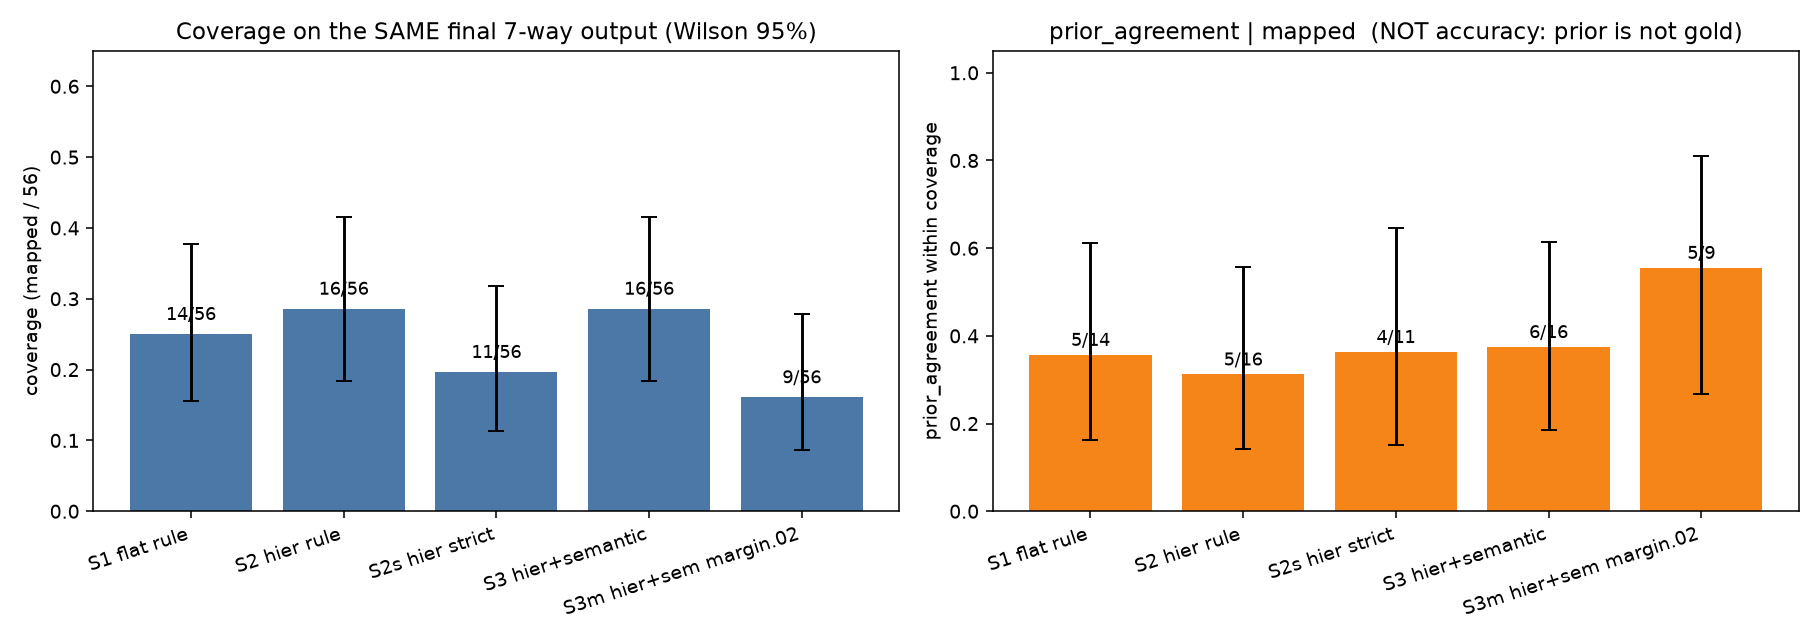

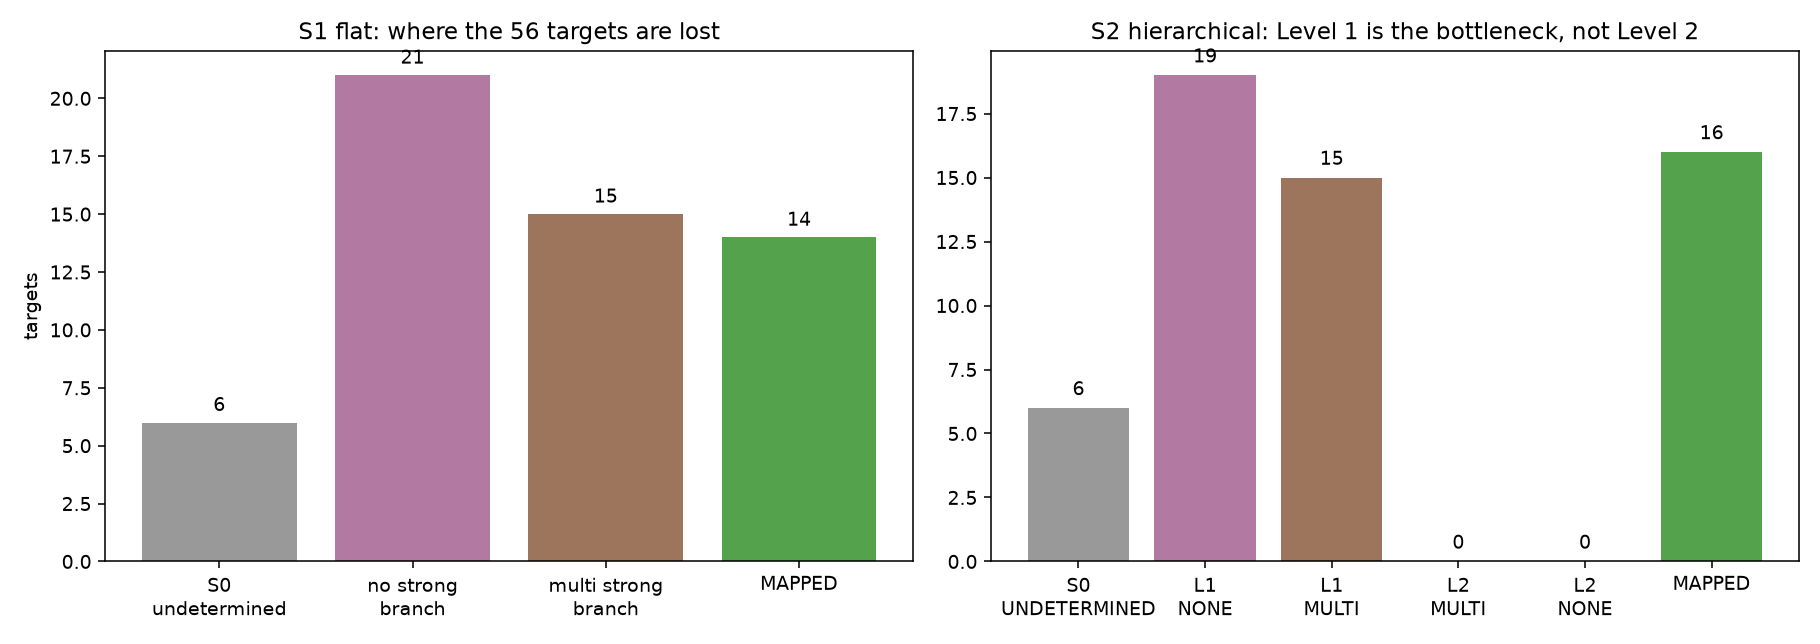

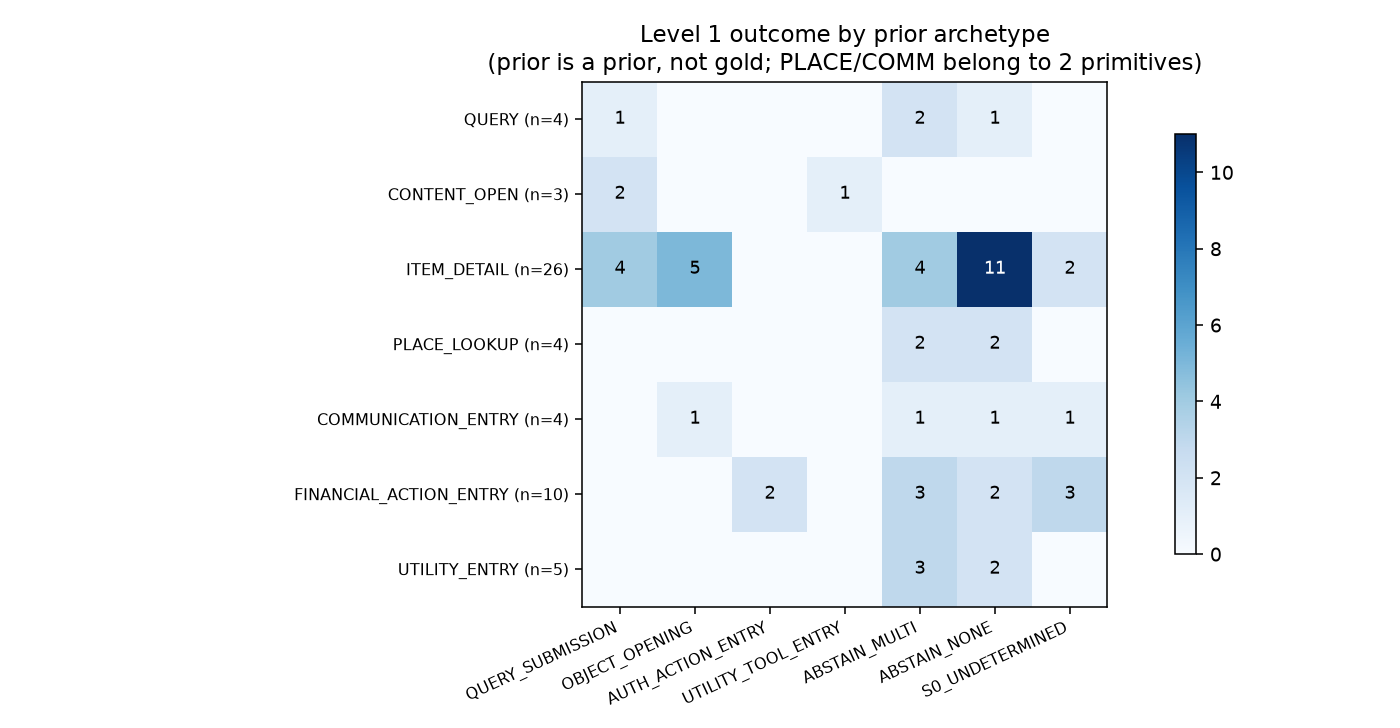

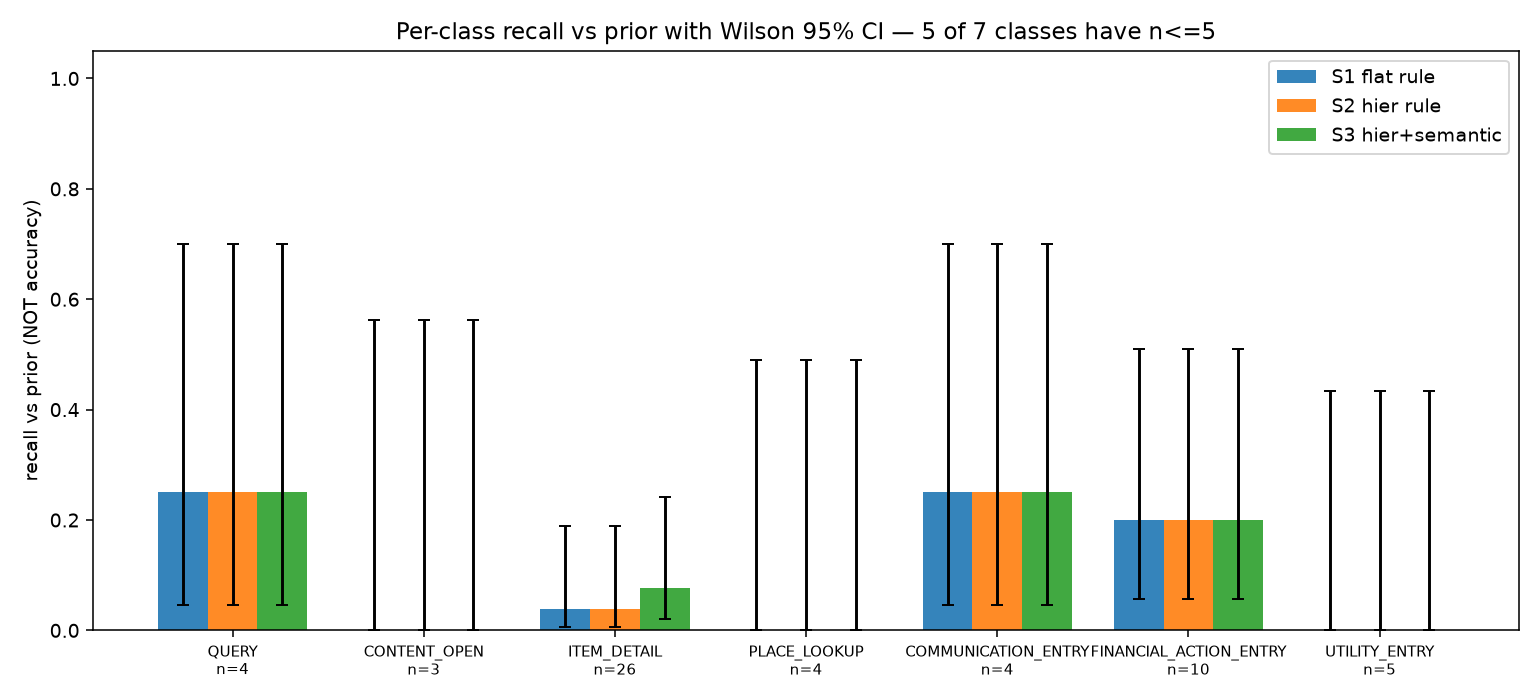

In [10]:
for f in ["RF2_D_structure_comparison", "RF2_D_information_loss",
          "RF2_D_level1_confusion", "RF2_D_per_class"]:
    display(Image(filename=str(RD / "figures" / f"{f}.png")))

## 10. 판정 · limitation · production implication

In [11]:
display(Markdown(f"### 최상위 verdict: **{doc['verdict']}**\n\n{doc['verdict_scope']}"))
for h, v in doc["hypothesis_verdicts"].items():
    display(Markdown(f"**{h} → `{v['verdict']}`**\n\n{v['why']}"))
display(Markdown("### Limitation\n\n" + doc["limitation"]))
display(Markdown("### Production implication\n\n" + doc["production_implication"]))
display(Markdown("### 추가 연구질문\n\n" + "\n".join("- " + q for q in doc["next_questions"])))
display(Markdown("### 방화벽\n\n" + doc["firewall"]["note"]))

### 최상위 verdict: **NOT_SUPPORTED**

H-RF2-D-HIERARCHY = '계층 구조가 관측 evidence 와 더 잘 맞는다' 에 대한 판정. REFUTED 가 아니라 NOT_SUPPORTED 인 이유: n=56, class 5 개가 n≤5, prior 가 gold 가 아니어서 '계층이 나쁘다' 를 확증할 검정력이 없다. 방향은 일관되게 '이득 없음~약한 손해' 다.

**H-D1_HIERARCHY_HELPS → `PARTIALLY_SUPPORTED`**

문자 그대로의 조건 중 'coverage 를 올린다' 만 아주 약하게 충족한다 (flat 14/56 → hier 16/56, Wilson CI 가 거의 완전히 겹친다). 그러나 늘어난 2 건은 **둘 다 prior 와 불일치**해서 prior_agreement 는 전혀 오르지 않았고(overall 5/56 → 5/56), coverage 내부 agreement 는 오히려 내려갔다(5/14 → 5/16). 두 구조가 **같이 매핑한 14 건에서는 예측이 100% 동일**하다(both_mapped_diff=0). 즉 계층은 같은 coverage 구간에서 정보를 전혀 더하지 않는다.

**H-D2_LEVEL1_IS_EASY → `REFUTED`**

Level 1 은 쉽지 않다. 56 건 중 16 건(28.6%)에서만 유일 primitive 가 닫히고 40 건은 L1 에서 막힌다(multi 15 · none 19 · S0 6). 게다가 닫힌 16 건에서의 prior primitive 일치는 9/16=0.5625 로, 항상 L1_OBJECT_OPENING 이라고 찍는 다수결 기준선 13/16=0.8125 **보다 낮다**. 'Level 2 가 어렵다' 는 후반부는 성립하지만(L2 통과 16 건 중 prior 일치 5), Level 2 조건부 coverage 1.0 은 L2 판별식을 상호배타적으로 선언한 **정의상 산물**이지 L2 가 쉽다는 증거가 아니다.

**H-D3_NO_GAIN → `SUPPORTED`**

동일 최종 7-way output 기준으로 두 구조는 실질적으로 같다. 교집합 14 건 예측 동일, flat 전용 매핑 0 건, hier 전용 매핑 2 건(둘 다 prior 불일치), McNemar 짝 불일치 b=0 c=0. 계층 구조는 정보를 늘리지 않았다. 오히려 L1 후보 제약은 semantic arm 에서 동일 16 건 기준 9/16 → 6/16 으로 **낮췄다**(불일치 4:1, exact p=0.375 — 방향은 음, 유의하지는 않음).

### Limitation

1) prior_archetype 은 gold label 이 아니라 business-domain 에서 유도된 prior 이며, 이 데이터에서 prior_archetype 은 prior_business_domain 과 1:1 로 붙어 있다. 따라서 prior_agreement 는 '규칙이 도메인 prior 를 재현하는가' 에 가깝고 '옳은가' 가 아니다. 2) 입력이 landing snapshot 1 장이라 SSOT §5 의 endpoint(상태전이)를 관측할 수 없어 모든 E 를 'endpoint-enabling control 존재' 로 강등했다 — coverage 를 낙관적으로 올리는 강등이다. 3) n=56, 7 class 중 5 개가 n≤5 라 per-class Wilson CI 가 거의 [0,1] 폭이다. 4) Level 1 정의는 SSOT §5 endpoint 절에서 유도했지만 primitive 경계 자체는 이 실험의 DEFINITION 이며 독립 검증을 받지 않았다. 다른 primitive 분할이면 결론이 달라질 수 있다. 5) L2 semantic 은 calibration split 없이 prototype 과 margin 임계 0.02 를 사전 선언만 했다. 이 임계는 운영 threshold 가 아니다.

### Production implication

SSOT 01 §5 의 flat branch tree 를 계층 구조로 바꿀 근거가 이 데이터에는 없다. SSOT 를 바꾸지 말 것. 병목은 구조가 아니라 evidence 다 — landing snapshot 은 representative function 이 아니라 '랜딩 페이지가 지금 제공하는 affordance' 만 담고 있고, 그 둘은 체계적으로 다르다(쇼핑·콘텐츠 서비스의 랜딩에서 가장 뚜렷한 컨트롤이 검색창이라 L1 이 QUERY_SUBMISSION 으로 흡수한다). 또한 SSOT §5 branch tree 는 primitive 위의 분할이 아니다 — PLACE_LOOKUP 과 COMMUNICATION_ENTRY 가 primitive 2 개에 걸쳐 있어, 계층을 강제하면 flat 이 확정하던 건까지 잃는다(hier_strict 에서 3 건 손실).

### 추가 연구질문

- RQ-a: representative function 은 landing snapshot 이 아니라 1-hop 전이 후의 상태에서만 관측 가능한가? (endpoint 강등을 풀 수 있는 최소 수집 단위는 무엇인가)
- RQ-b: L1 이 QUERY_SUBMISSION 으로 흡수하는 현상은 '검색창 우선' 이라는 랜딩 디자인 관행의 측정인가, 매핑 규칙의 결함인가? 두 가설을 가르는 관측은 무엇인가.
- RQ-c: SSOT §5 를 primitive 분할이 되도록 재정의하면(PLACE_LOOKUP 을 PLACE_QUERY / PLACE_DETAIL 로 쪼개는 등) 계층 손실이 사라지는가? 이는 7 archetype 변경이므로 A 결정 사항이며 D 는 제안만 한다.
- RQ-d: 계층 없이 7-way semantic argmax 가 강제매핑 기준 29/56 를 얻는 것과 규칙이 5/56 에 그치는 것의 차이는 '규칙이 abstain 하기 때문' 인가 '규칙 predicate 이 틀렸기 때문' 인가.

### 방화벽

holdout label · LABEL_SPLIT_FROZEN* · HOLDOUT_FOR_C* · RAW_L1~L4* · PACKET_L* · *_OVERLAP* · PRECEDENCE_CONTESTED* · CALIBRATION_FOR_B* · control/ 아래 파일을 하나도 열지 않았다. REAL_TARGET 에 접속하지 않았다. gold label 을 만들지 않았다.